<a href="https://colab.research.google.com/github/bynada/late-shipment-analysis/blob/main/Late_Shipment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Late Shipment Analysis

This project analyzes delivery data to identify key factors that contribute to late shipments.  
The goal is to help improve delivery performance and customer satisfaction using exploratory data analysis (EDA) and predictive modeling.


# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 2. Load Dataset

In [2]:
dataset_url = 'https://docs.google.com/spreadsheets/d/1gNHzc6AscFqhYeWvVFAR58jQg94k8qnNSmEOeGpQMO8/edit?gid=786563236#gid=786563236'
dataset_csv = dataset_url.replace('/edit?gid=', '/export?format=csv&gid=')

df = pd.read_csv(dataset_csv)
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


# 3. Data Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


# 4. Data Cleaning

In [4]:
# Convert date columns

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], format='%m/%d/%Y %H:%M')
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], format='%m/%d/%Y %H:%M')

In [5]:
# Handle missing values

df = df.drop(columns=['Product Description', 'Order Zipcode'])
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(df['Customer Zipcode'].mode()[0])

In [6]:
# Check duplicates

print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


# 5. Feature Engineering

In [8]:
# Calculate Shipping Delay

df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['is_late'] = (df['shipping_delay'] > 0).astype(int)

In [9]:
# Create time between order & Shipment

df['Order_to_Shipment_Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.total_seconds() / 3600

# 6. Exploratory Data Analysis (EDA)

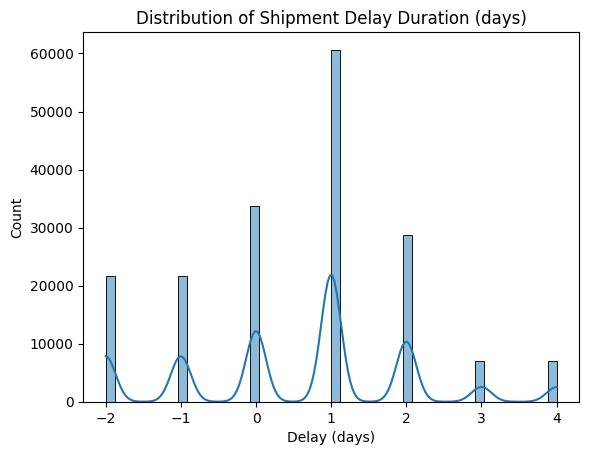

In [10]:
# Distribution of delays

sns.histplot(df['shipping_delay'], bins=50, kde=True)
plt.title('Distribution of Shipment Delay Duration (days)')
plt.xlabel('Delay (days)')
plt.show()

In [11]:
# Late delivery late

print(f"Overall Late Delivery Rate: {df['is_late'].mean():.2%}")

Overall Late Delivery Rate: 57.28%


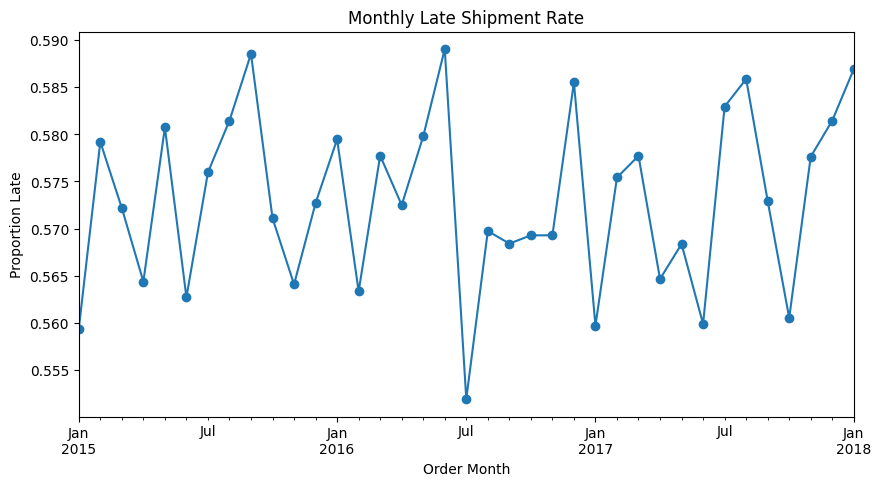

In [12]:
# Monthly Trends

df['order_month'] = df['order date (DateOrders)'].dt.to_period('M')
monthly_late_rate = df.groupby('order_month')['is_late'].mean()

monthly_late_rate.plot(marker='o', figsize=(10,5))
plt.title('Monthly Late Shipment Rate')
plt.ylabel('Proportion Late')
plt.xlabel('Order Month')
plt.show()

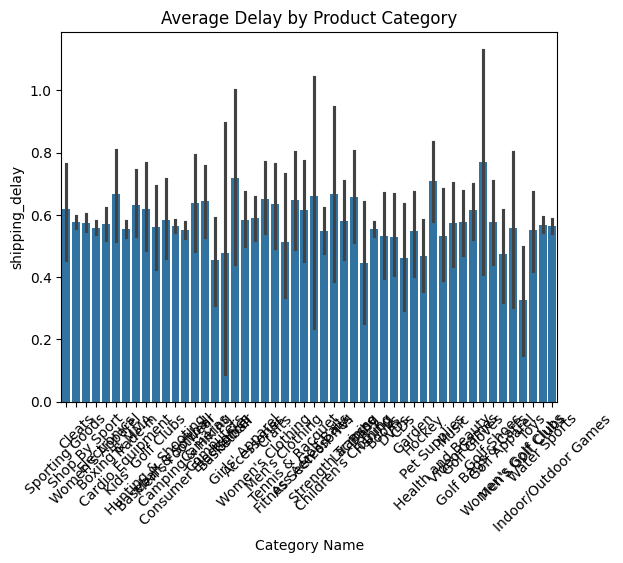

In [13]:
# By category

sns.barplot(x='Category Name', y='shipping_delay', data=df)
plt.xticks(rotation=45)
plt.title('Average Delay by Product Category')
plt.show()

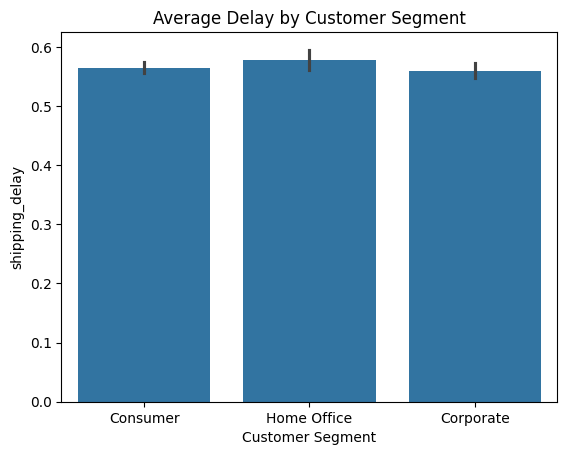

In [14]:
# By segment

sns.barplot(x='Customer Segment', y='shipping_delay', data=df)
plt.title('Average Delay by Customer Segment')
plt.show()

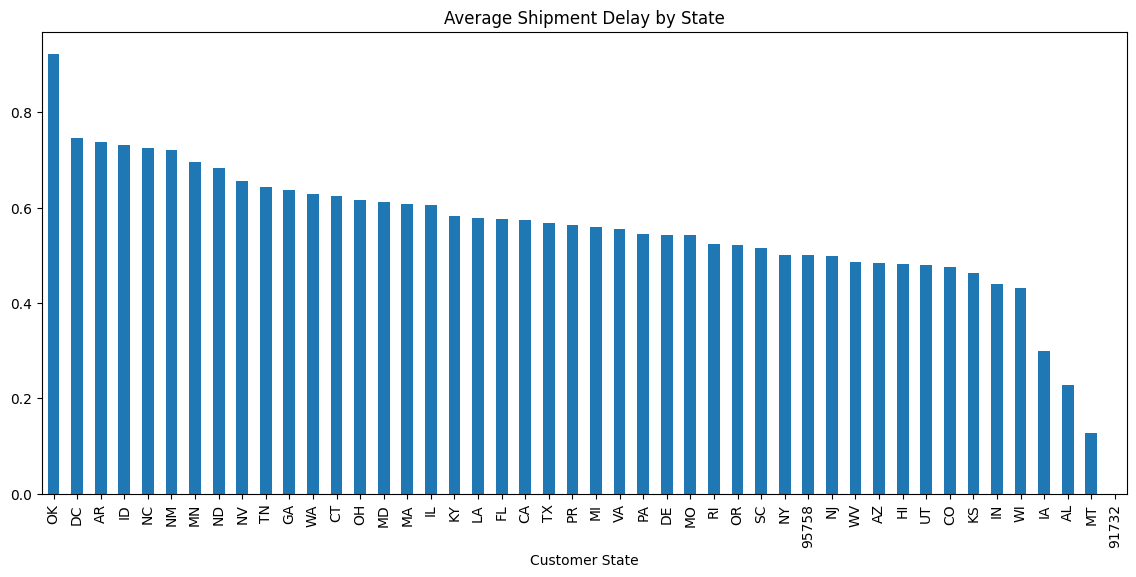

In [15]:
# By state

state_delay = df.groupby('Customer State')['shipping_delay'].mean().sort_values(ascending=False)
state_delay.plot(kind='bar', figsize=(14,6))
plt.title('Average Shipment Delay by State')
plt.show()

# 7. Predictive Modeling

In [16]:
# Feature & target selection

target = 'is_late'
features = ['Days for shipment (scheduled)', 'Shipping Mode', 'Order Item Quantity',
            'Order Item Discount Rate', 'Order Item Product Price',
            'Order Item Profit Ratio', 'Order Profit Per Order', 'Product Price',
            'Benefit per order', 'Sales per customer', 'Order_to_Shipment_Time']

X = df[features].copy()
y = df[target]

In [17]:
# Encode categorical feature

X['Shipping Mode'] = X['Shipping Mode'].str.strip()
encoder = OrdinalEncoder(categories=[['Standard Class', 'Second Class', 'First Class', 'Same Day']])
X['Shipping Mode'] = encoder.fit_transform(X[['Shipping Mode']])

In [18]:
# Scale numeric features

num_features = [col for col in X.columns if col != 'Shipping Mode']
scaler = MinMaxScaler()
X[num_features] = scaler.fit_transform(X[num_features])

In [19]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
# Logistic regression + feature selection

lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_]
print("Selected Features:", list(selected_features))

Selected Features: ['Days for shipment (scheduled)', 'Shipping Mode', 'Order Profit Per Order', 'Sales per customer', 'Order_to_Shipment_Time']


In [22]:
# Initialize logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Model intercept
print("Intercept:", model.intercept_)

# Model coefficients
# Create a DataFrame to display coefficients with feature names
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})
print(coefficients.sort_values(by='Coefficient', key=abs, ascending=False))

Intercept: [-3.59387349]
                          Feature  Coefficient
10         Order_to_Shipment_Time    48.705909
0   Days for shipment (scheduled)   -31.616535
1                   Shipping Mode     1.157066
8               Benefit per order     0.259415
6          Order Profit Per Order     0.259415
5         Order Item Profit Ratio    -0.226824
4        Order Item Product Price    -0.225670
7                   Product Price    -0.225670
9              Sales per customer    -0.218604
2             Order Item Quantity    -0.106792
3        Order Item Discount Rate    -0.031286


In [24]:
# To see how well the model performs

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9720806558830046
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     23071
           1       0.97      0.98      0.98     31085

    accuracy                           0.97     54156
   macro avg       0.97      0.97      0.97     54156
weighted avg       0.97      0.97      0.97     54156



<Figure size 600x500 with 0 Axes>

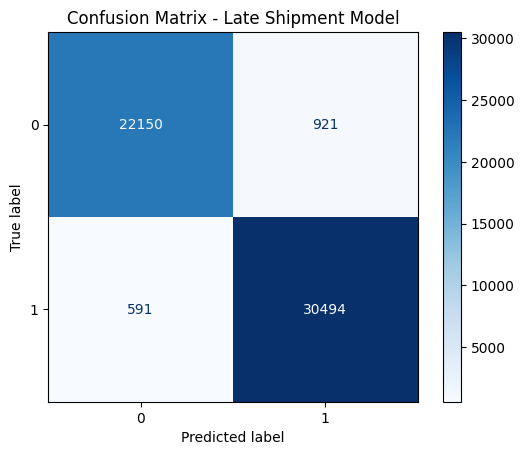

In [25]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Plot
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Late Shipment Model')
plt.show()

# 8. Conclusion

### Key Insights
- Around 57% of total shipments were late, indicating more than half of deliveries missed their scheduled date.  
- The most influential factors are **Order-to-Ship-Time**, **Days for shipment (scheduled)** and **Shipping Mode**.  
- Logistic Regression achieved an accuracy of 97%, showing high reliability in predicting whether a shipment will be late, though some patterns might still be non-linear.

### Next Steps
- Try tree-based models (Random Forest, XGBoost) to capture non-linear effects.
- Add features like region or order priority.
